#### Примечание к эксперименту: в текущей реализации код не защищён от краевых случаев генерации перспективных искажений, bg loss может "взорваться" даже с клиппингом, в случае если вылезет nan при обучении - копать в эту сторону

In [1]:
import sys, os, json, torch, random
import numpy as np
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader
from omegaconf import OmegaConf

warnings = __import__('warnings')
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../../..'))

In [2]:
from DL.models.custom_classifier_from_config import CustomClassifierFromConfig
from DL.trainers.model_trainer import ModelTrainer
from DL.data.combined_dataset import CombinedDataset
from DL.loggers.experiment_logger import ExperimentLogger
from DL.visualization.visualizer import ExperimentVisualizer

In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42) # Фиксируем сид

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device: ', device)

Device:  cuda


In [5]:
# Инициализация Менеджера Эксперимента и Визуализатора
experiment_name = "lenet_4kb_vs_2kb_bg_loss_with_perspective_augmentations"
logger = ExperimentLogger(experiment_name, base_dir=".")
visualizer = ExperimentVisualizer(logger)

In [6]:
logger.log("Инициализация данных...")

perspective_transform = T.RandomPerspective(distortion_scale=0.5, p=0.8)

train_dataset = CombinedDataset(75000, 42, transform=perspective_transform)
test_dataset = CombinedDataset(25000, 123, transform=perspective_transform)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [7]:
def train_model(config_name: str, model_tag: str, alpha: float, epochs: int = 15):
    config_path = f'../../../DL/configs/lenet/{config_name}'
    conf = OmegaConf.load(config_path)
    conf.num_classes = len(train_dataset.char_to_idx)

    logger.save_config(OmegaConf.to_container(conf), filename=f"config_{model_tag}.json")
    logger.log(f"=== Запуск обучения: {model_tag} | Alpha: {alpha} ===")

    model = CustomClassifierFromConfig(OmegaConf.to_container(conf)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4) # Сниженный LR

    trainer = ModelTrainer(
        model=model, optimizer=optimizer, criterion=nn.CrossEntropyLoss(), device=device,
        use_background_loss=True, bg_loss_alpha=alpha, bg_loss_n=2,
        logger=logger, visualizer=visualizer, model_name=model_tag # Передаем логгер и визуализатор!
    )

    trainer.fit(train_loader, test_loader, epochs=epochs)
    return model

# Обучение 4KB модели

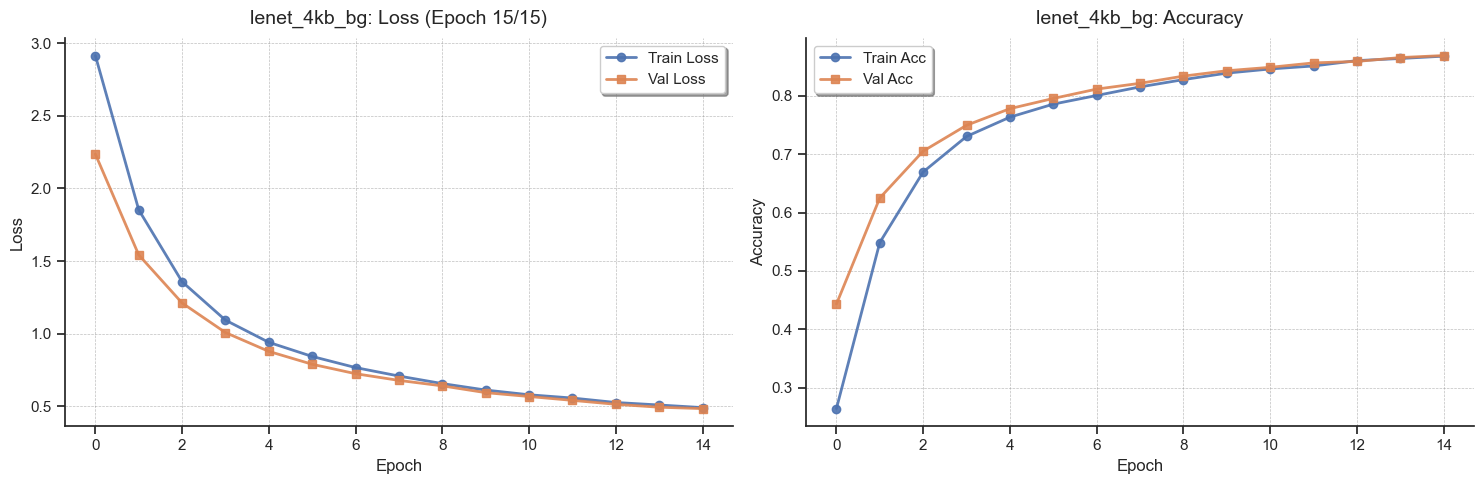

In [8]:
model_4kb = train_model('lenet_4kb.json', model_tag="lenet_4kb_bg", alpha=5.0)

## Визуализация на тесте

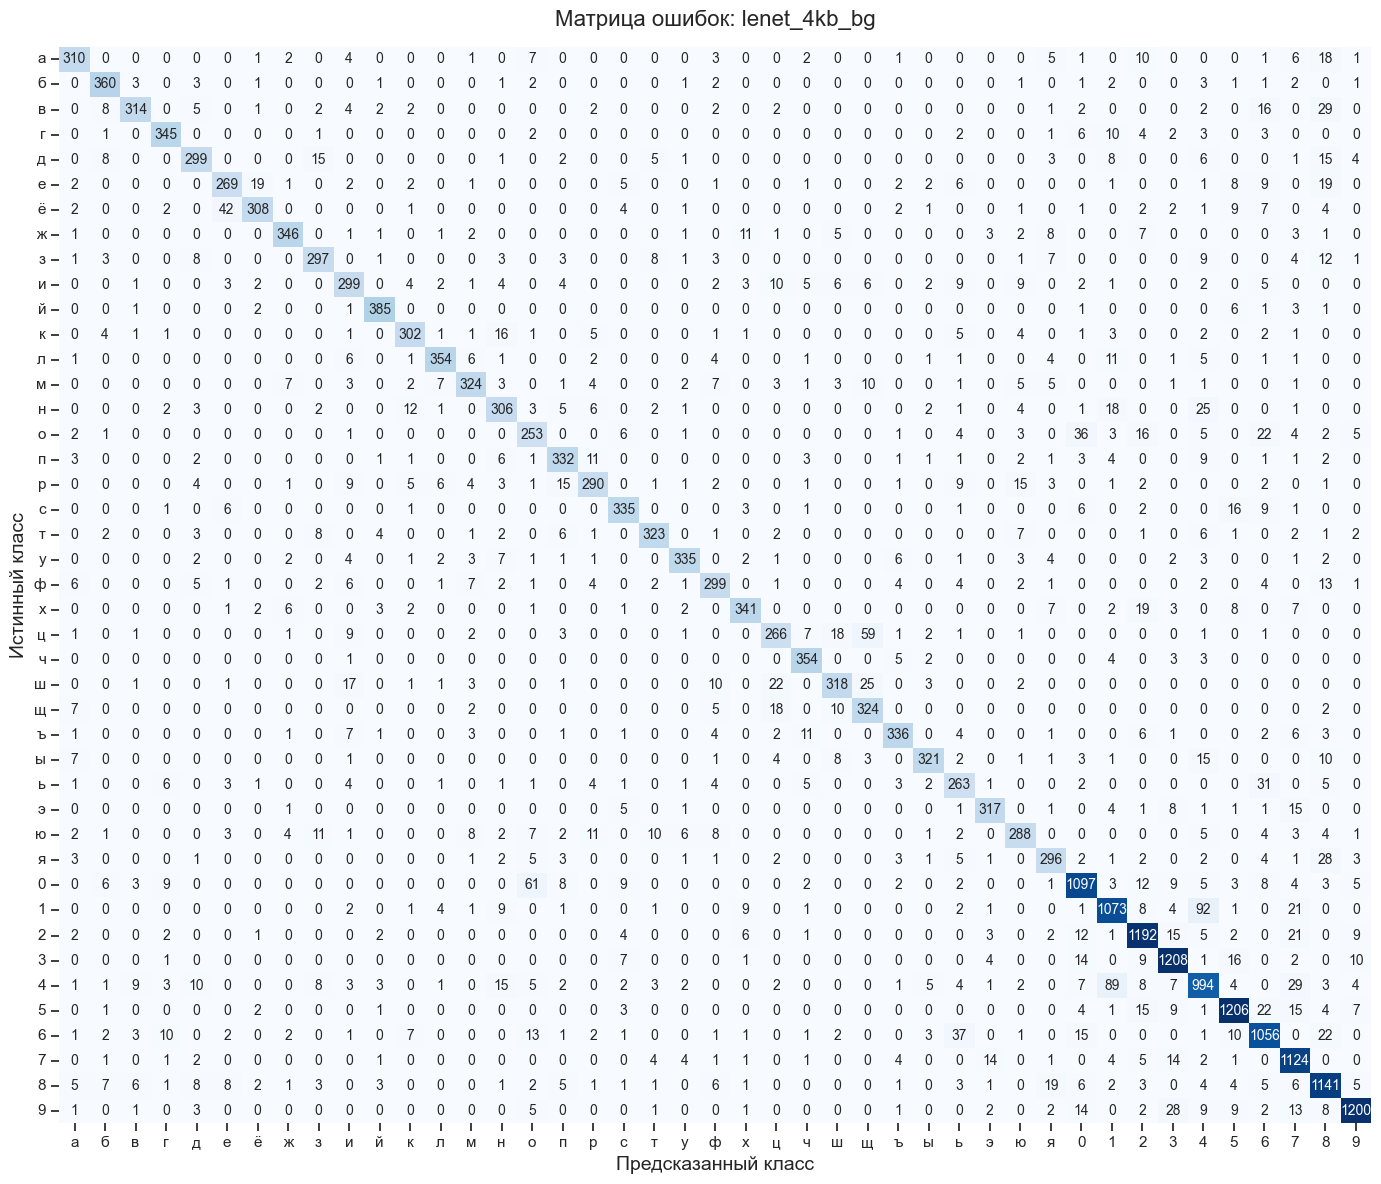

In [9]:
visualizer.plot_confusion_matrix(model_4kb, test_loader, test_dataset, device, model_name="lenet_4kb_bg")

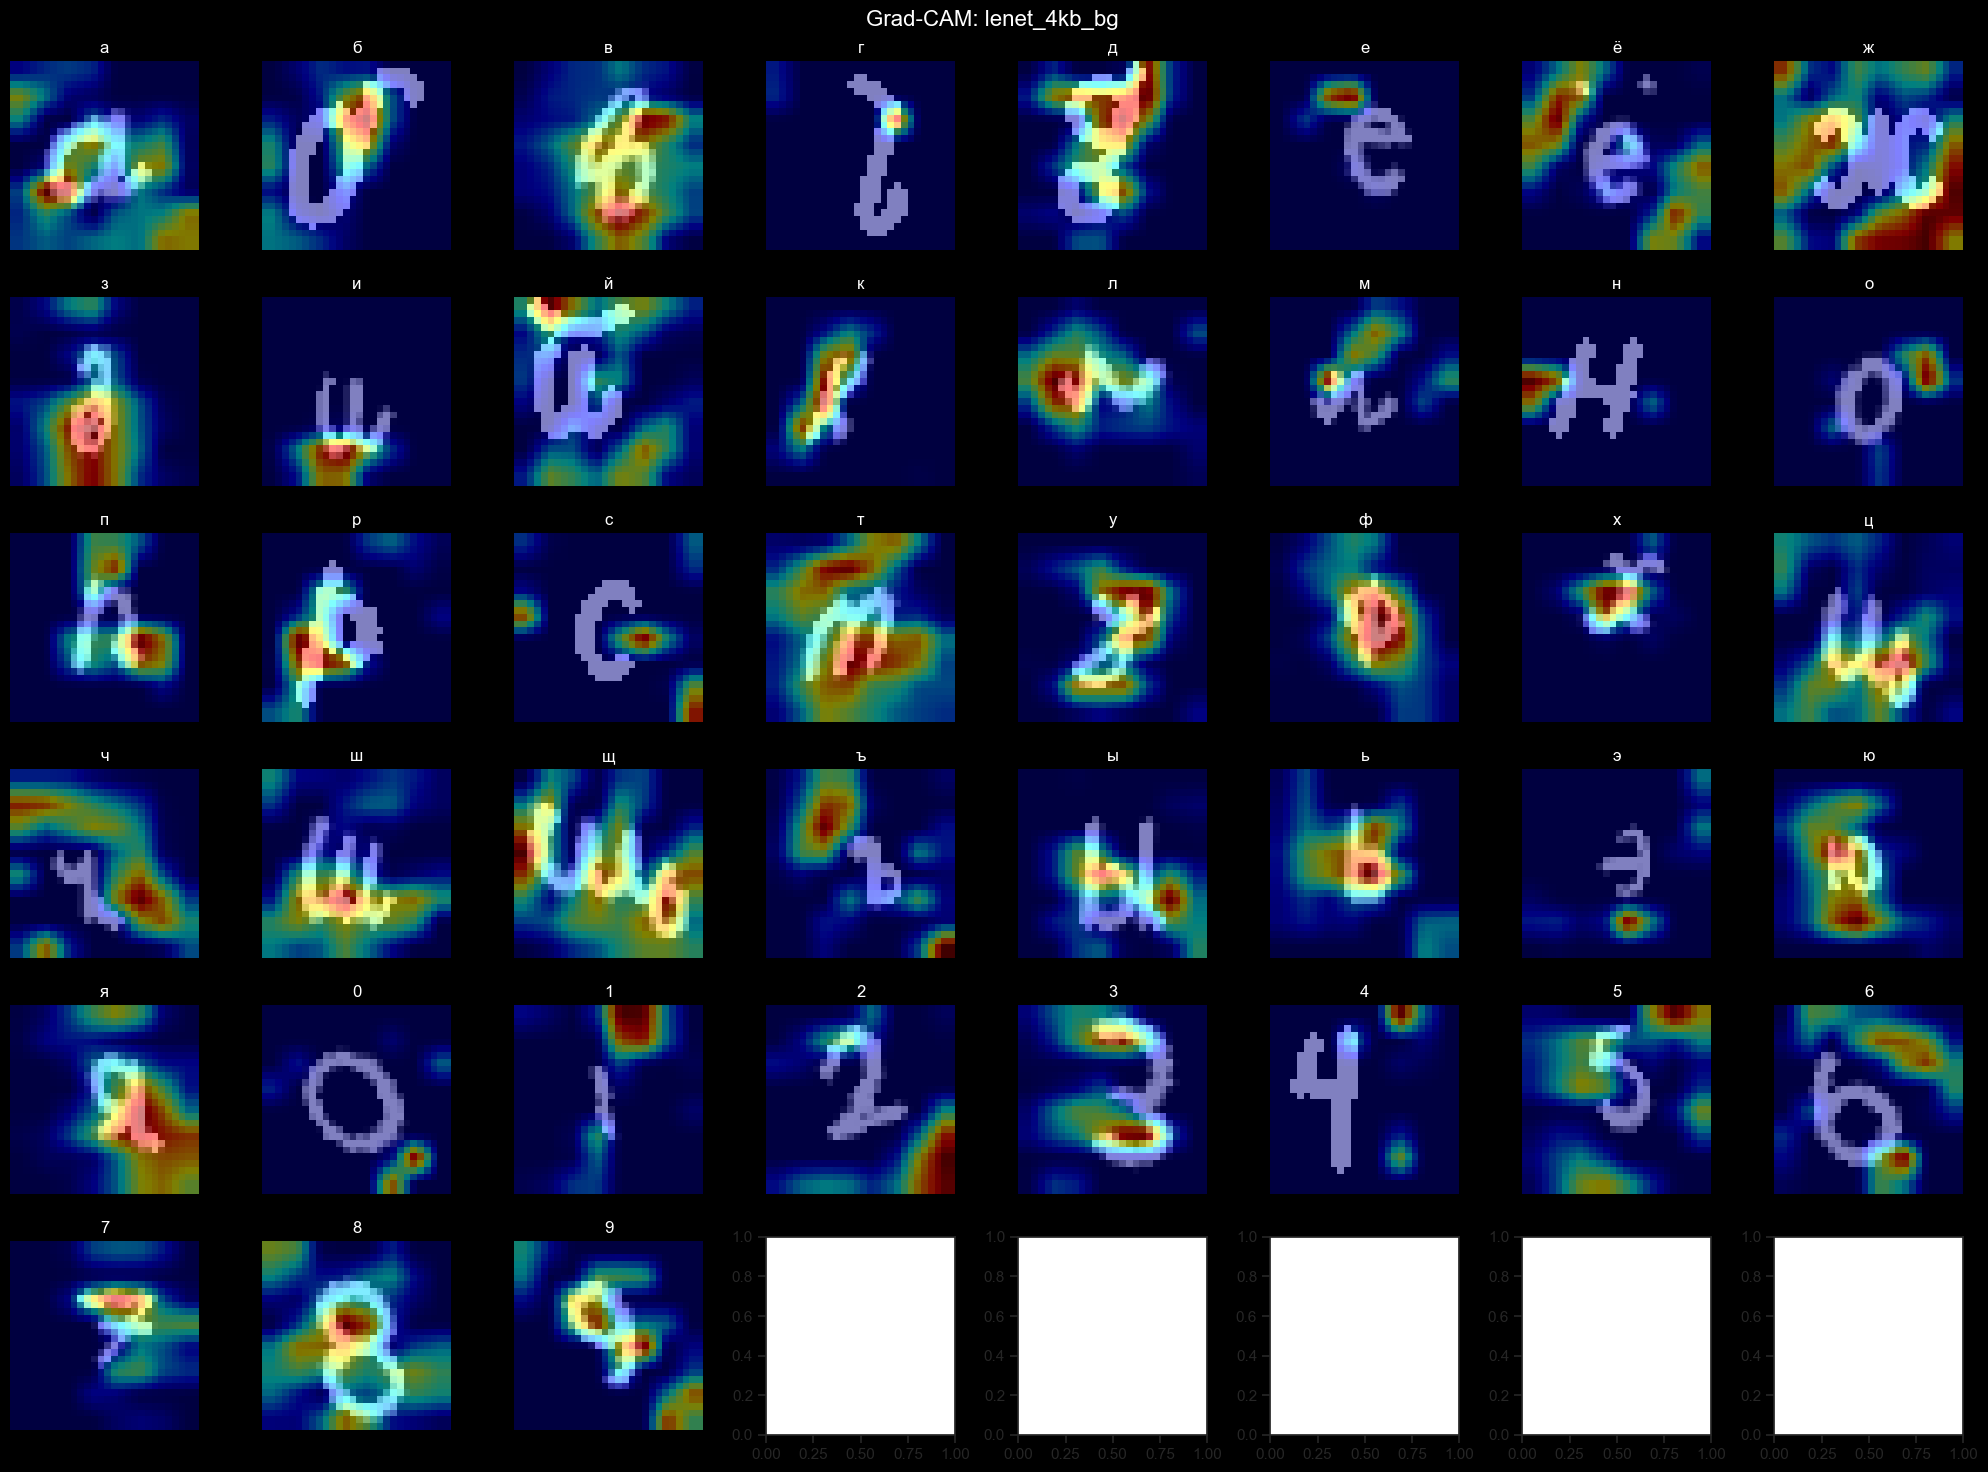

<Figure size 640x480 with 0 Axes>

In [14]:
visualizer.plot_gradcam(model_4kb, test_dataset, device, model_name="lenet_4kb_bg")

# Обучение 2KB модели

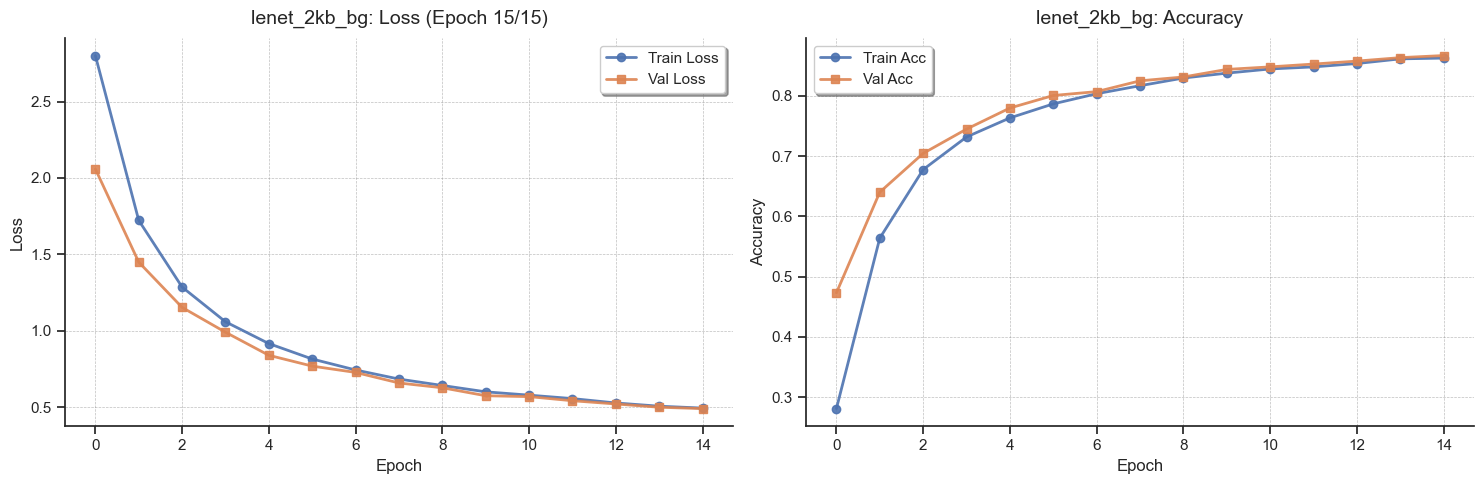

In [11]:
model_2kb = train_model('lenet_2kb.json', model_tag="lenet_2kb_bg", alpha=2.0)

## Визуализация на тесте

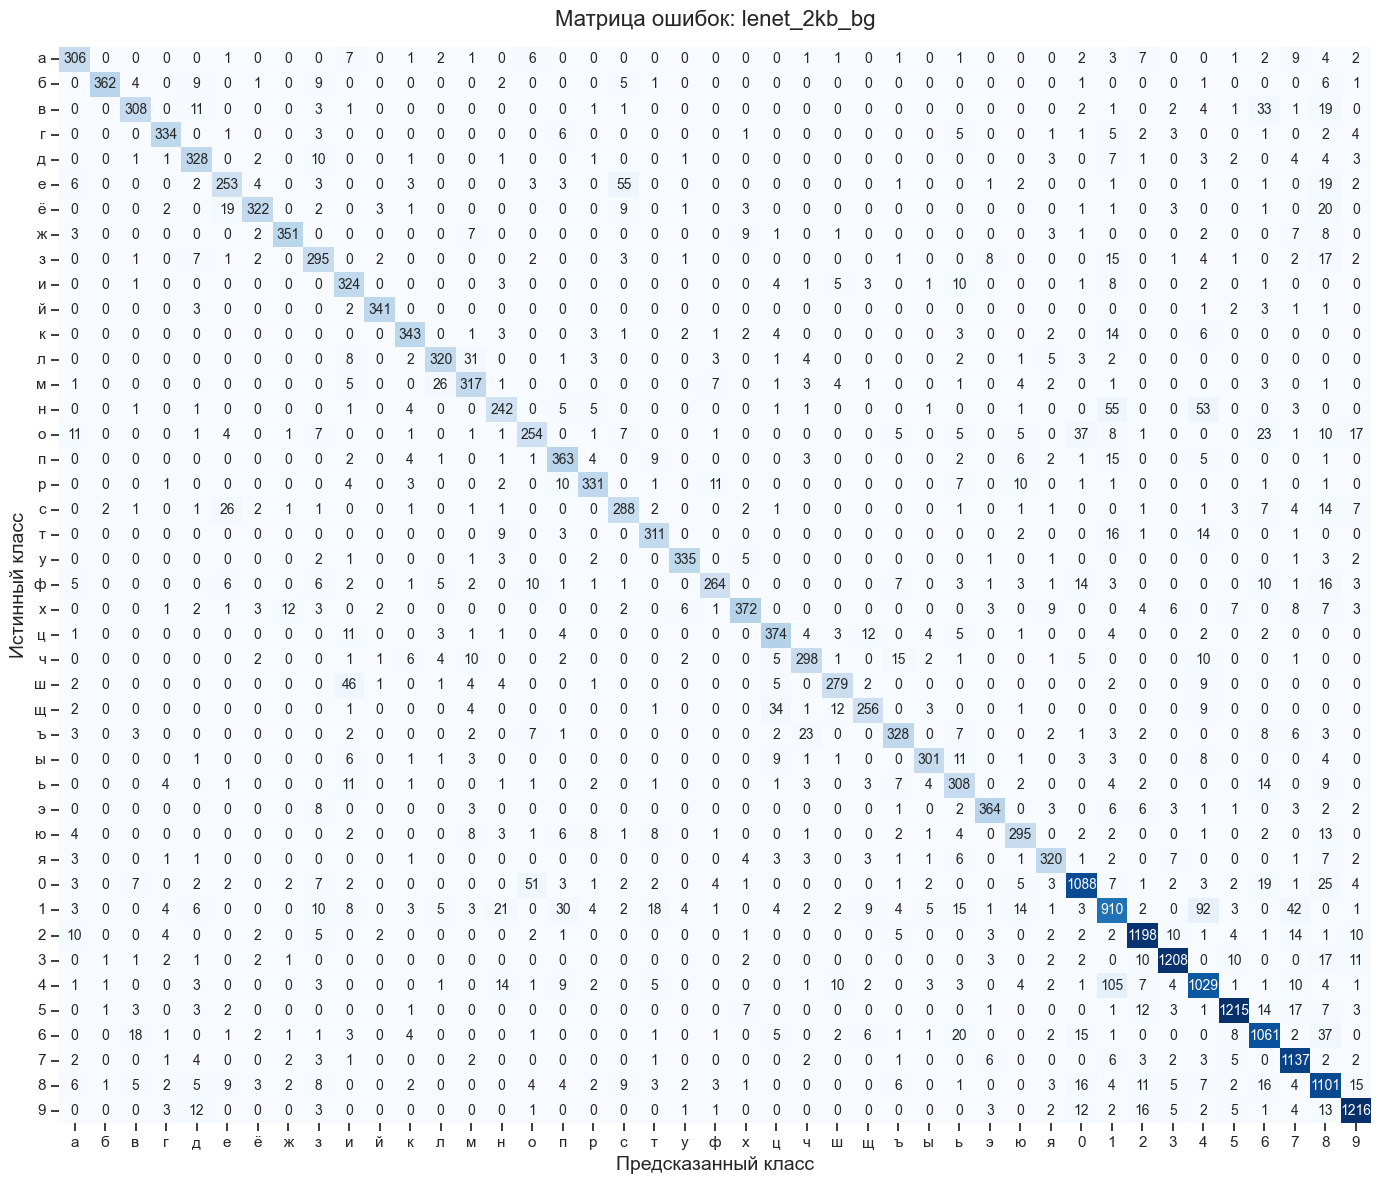

In [12]:
visualizer.plot_confusion_matrix(model_2kb, test_loader, test_dataset, device, model_name="lenet_2kb_bg")

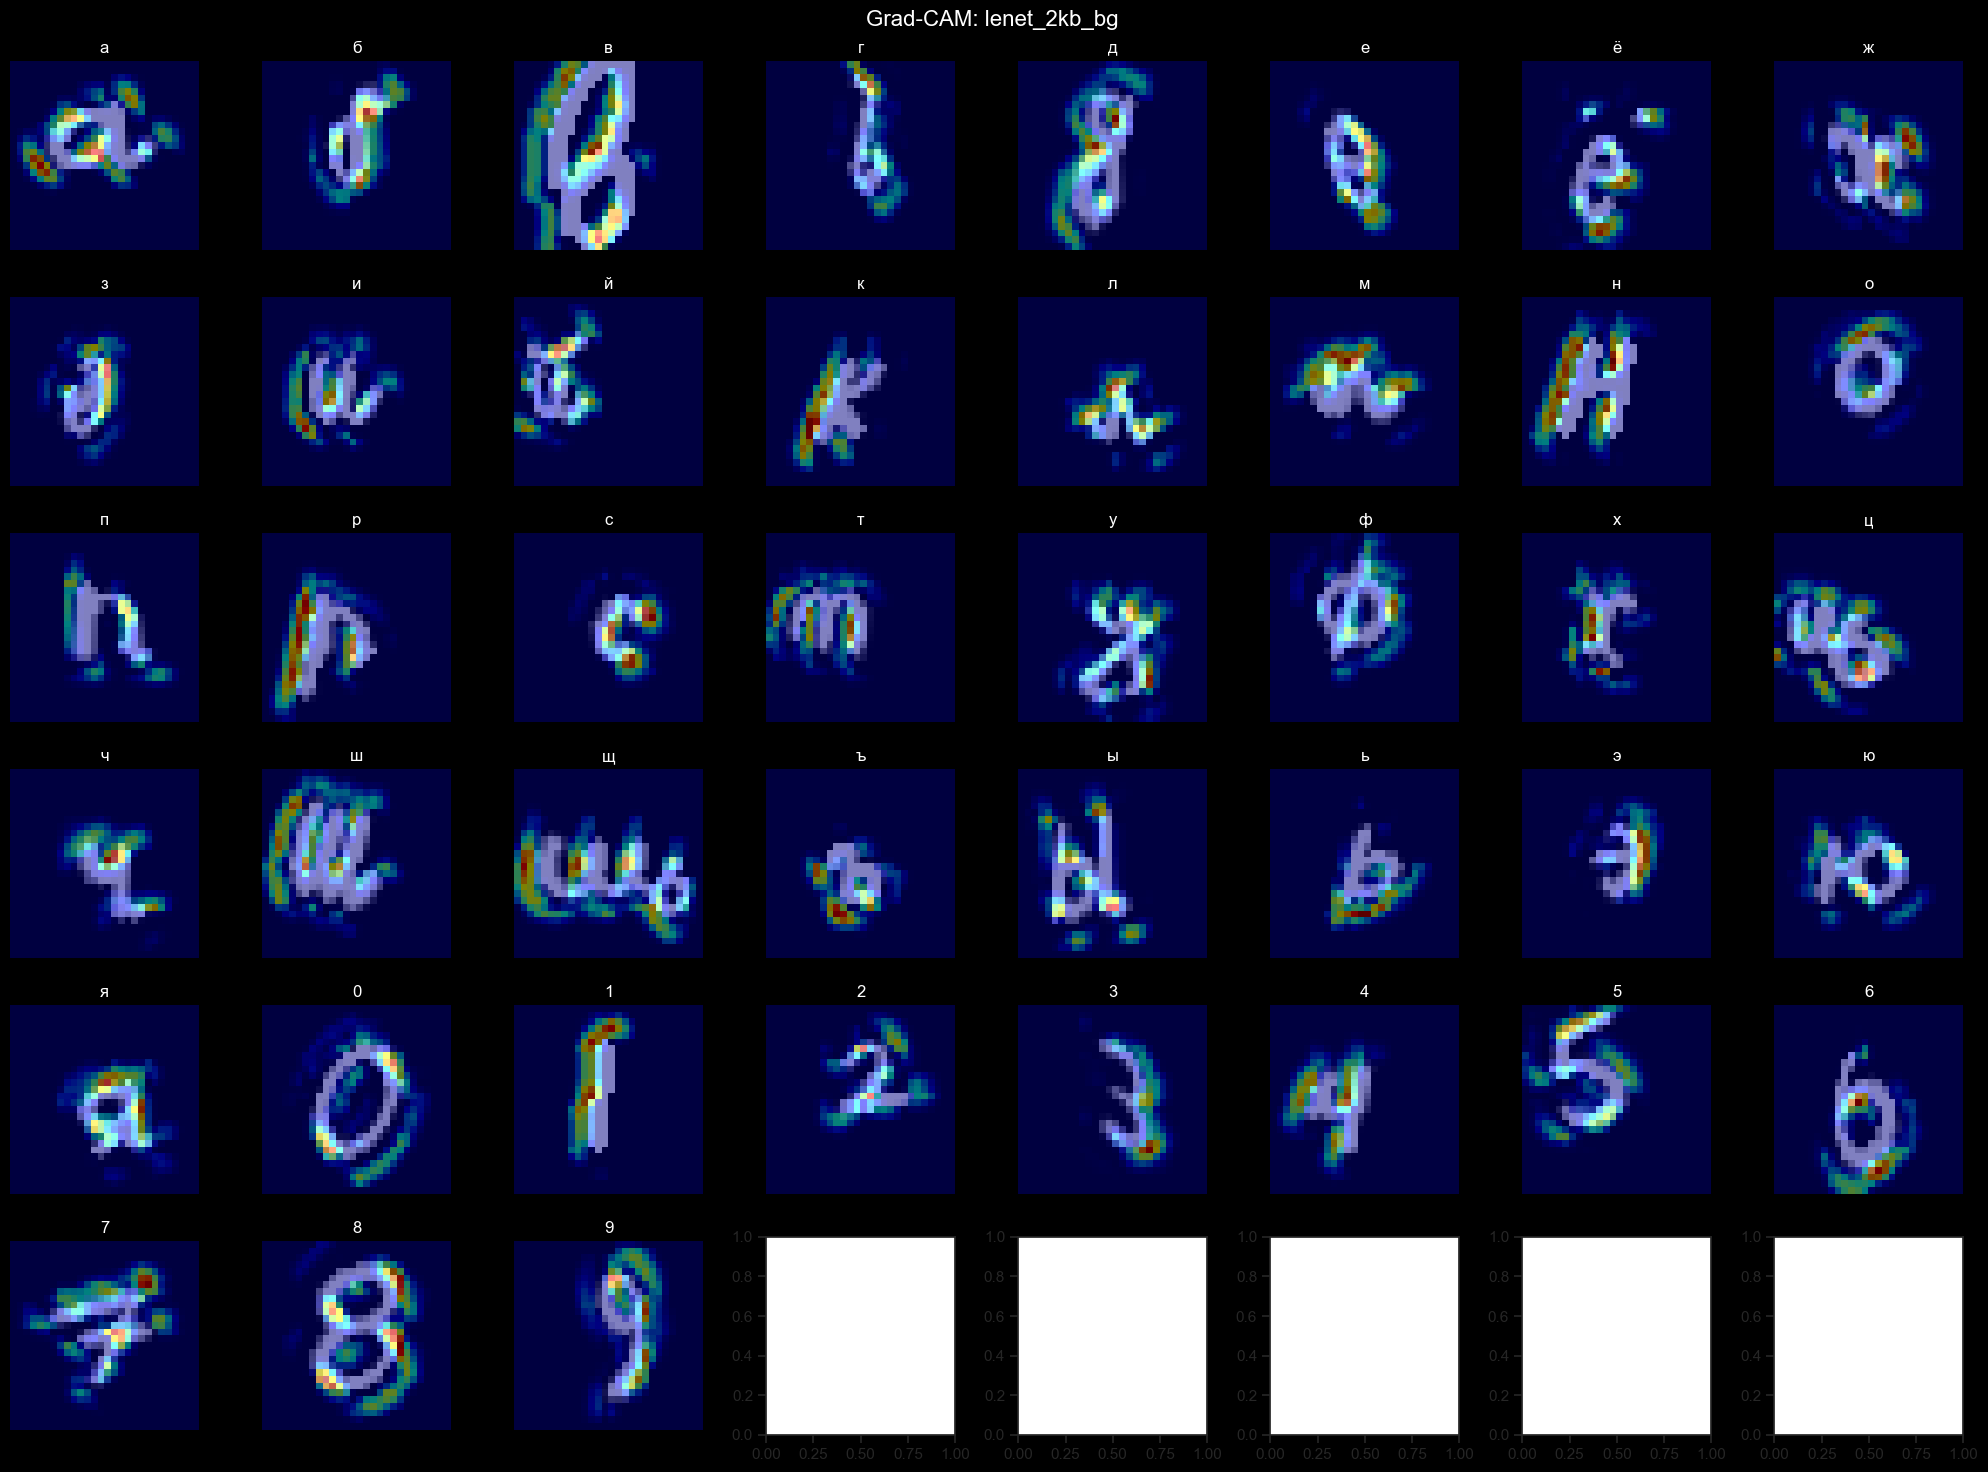

<Figure size 640x480 with 0 Axes>

In [13]:
visualizer.plot_gradcam(model_2kb, test_dataset, device, model_name="lenet_2kb_bg")